# Ivestigating a checkpoint of mopadi_v1

In mopadi_v1, the encoder and diffusion network are saved as a combined checkpoint (which is changed in mopadi_v2, there they are saved separately). The idea is to separate the checkpoint of a mopadi_v1 model into the encoder.ckpt and the diffusion_network.ckpt, because for future references, we only need the diffusion_network.ckpt.

In [1]:
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from huggingface_hub import hf_hub_download, login
from torchvision import transforms
import h5py

from mopadi.configs.templates import tcga_brca_autoenc
from mopadi.utils.encode import *

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [2]:
# download model files
autoenc_model_path = hf_hub_download(
    repo_id="KatherLab/MoPaDi",
    filename="brca_512_model/autoenc.ckpt",
)
print(f"Autoencoder's checkpoint downloaded to: {autoenc_model_path}")

Autoencoder's checkpoint downloaded to: /home/mala059b/.cache/huggingface/hub/models--KatherLab--MoPaDi/snapshots/5d8e775e24473c5d8f4c0c57fd5c865c3c2a4aab/brca_512_model/autoenc.ckpt


In [3]:
data_dir = "/data/horse/ws/mala059b-rna2wsi/data/TCGA/"

In [4]:
z = zipfile.ZipFile(os.path.join(data_dir, [f for f in os.listdir(data_dir) if f.lower().endswith('.zip')][0])); print(f"ZIP size: {os.path.getsize(z.filename)} bytes\nFiles: {len(z.namelist())}\nFirst file: {z.infolist()[0].filename} ({z.infolist()[0].file_size} bytes)")

ZIP size: 1164644379 bytes
Files: 2700
First file: tiler_params.json (352 bytes)


In [5]:
# pleae tell me about one png file the dimensions
with z.open([f for f in z.namelist() if f.lower().endswith('.png')][535]) as img_file:
    img = Image.open(img_file).convert("RGB")

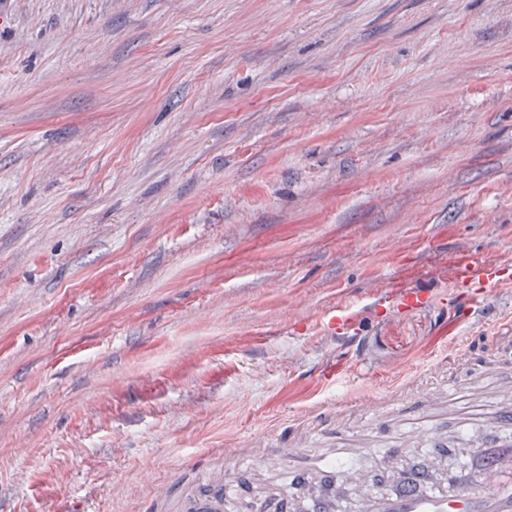

In [6]:
img

In [7]:
out_dir = Path("split_ckpts")
out_dir.mkdir(exist_ok=True)

ckpt = torch.load(autoenc_model_path, map_location="cpu")

# Get the state_dict (Lightning vs plain)
if isinstance(ckpt, dict) and "state_dict" in ckpt:
    sd = ckpt["state_dict"]
    wrapper = "lightning"
elif isinstance(ckpt, dict) and "model" in ckpt and isinstance(ckpt["model"], dict):
    sd = ckpt["model"]
    wrapper = "modelkey"
elif isinstance(ckpt, dict):
    sd = ckpt
    wrapper = "plain"
else:
    raise TypeError(f"Unsupported checkpoint type: {type(ckpt)}")

ENC_PREFIX = "model.encoder."

enc_sd = {k: v for k, v in sd.items() if k.startswith(ENC_PREFIX)}
rest_sd = {k: v for k, v in sd.items() if not k.startswith(ENC_PREFIX)}

print(f"Total params: {len(sd)}")
print(f"Encoder params: {len(enc_sd)}")
print(f"Rest params: {len(rest_sd)}")

if len(enc_sd) == 0:
    raise RuntimeError(f"No keys matched prefix '{ENC_PREFIX}'. Check your key names.")

def save_ckpt_like(original_ckpt, new_sd, out_path: Path):
    if isinstance(original_ckpt, dict) and "state_dict" in original_ckpt:
        new_ckpt = dict(original_ckpt)
        new_ckpt["state_dict"] = new_sd
        # drop optimizer/scheduler states to avoid confusion & large files (optional but recommended)
        new_ckpt.pop("optimizer_states", None)
        new_ckpt.pop("lr_schedulers", None)
        torch.save(new_ckpt, out_path)
    else:
        torch.save(new_sd, out_path)

save_ckpt_like(ckpt, enc_sd, out_dir / "encoder_only.ckpt")
save_ckpt_like(ckpt, rest_sd, out_dir / "diffusion_without_encoder.ckpt")
print("Saved:", out_dir / "encoder_only.ckpt", "and", out_dir / "diffusion_without_encoder.ckpt")

Total params: 1413
Encoder params: 116
Rest params: 1297
Saved: split_ckpts/encoder_only.ckpt and split_ckpts/diffusion_without_encoder.ckpt
